| **Column Name**              | **Description**                                                                |
| ---------------------------- | ------------------------------------------------------------------------------ |
| **personality_type**         | Target variable: Categorizes individuals as Introvert, Extrovert, or Ambivert. |
| **social_energy**            | Tendency to gain energy from social interaction (scale from 0–10).             |
| **alone_time_preference**    | Comfort with solitude.                                                         |
| **talkativeness**            | Propensity to engage in conversation.                                          |
| **deep_reflection**          | Frequency of deep or introspective thinking.                                   |
| **group_comfort**            | Ease in group environments.                                                    |
| **party_liking**             | Enjoyment of parties and social events.                                        |
| **listening_skill**          | Active listening ability.                                                      |
| **empathy**                  | Ability to understand others’ emotions.                                        |
| **creativity**               | Tendency toward creative thinking.                                             |
| **organization**             | Preference for order, structure, and plans.                                    |
| **leadership**               | Comfort in leading others.                                                     |
| **risk_taking**              | Willingness to take risks.                                                     |
| **public_speaking_comfort**  | Comfort level in public speaking situations.                                   |
| **curiosity**                | Interest in learning or exploring.                                             |
| **routine_preference**       | Preference for routine vs. spontaneity.                                        |
| **excitement_seeking**       | Desire for new and stimulating experiences.                                    |
| **friendliness**             | General social warmth and approachability.                                     |
| **emotional_stability**      | Ability to remain calm and balanced under stress.                              |
| **planning**                 | Tendency to plan ahead.                                                        |
| **spontaneity**              | Acting on impulse or without planning.                                         |
| **adventurousness**          | Willingness to try new and risky activities.                                   |
| **reading_habit**            | Frequency of reading books or articles.                                        |
| **sports_interest**          | Level of interest in sports or physical activities.                            |
| **online_social_usage**      | Time spent on social media and online interaction.                             |
| **travel_desire**            | Interest in travel and exploring new places.                                   |
| **gadget_usage**             | Frequency of gadget or tech device use.                                        |
| **work_style_collaborative** | Preference for teamwork vs. solo work.                                         |
| **decision_speed**           | How quickly decisions are made.                                                |
| **stress_handling**          | Ability to manage stress effectively.                                          |


**The goal of the project is to classify individuals into Introvert,  Ambivert and Extrovert categories based on a variety of behavioural and psycological features**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Loading and Inspecting the Data

In [2]:
df = pd.read_csv("personality_synthetic_dataset.csv")

In [3]:
df.head()

,personality_type,social_energy,alone_time_preference,talkativeness,deep_reflection,group_comfort,party_liking,listening_skill,empathy,creativity,...,spontaneity,adventurousness,reading_habit,sports_interest,online_social_usage,travel_desire,gadget_usage,work_style_collaborative,decision_speed,stress_handling
0,Extrovert,6.794295,3.854670,8.725446,2.515151,7.097368,8.588762,6.774799,6.430132,6.142968,...,4.853313,8.257134,5.270555,10.000000,9.154296,4.816422,9.191711,8.313590,8.032376,7.176905
1,Ambivert,6.378988,5.731157,7.029529,7.274493,4.111199,3.258248,5.550909,3.958179,6.149457,...,6.067201,6.289347,5.753165,5.334303,4.683781,4.725666,5.956141,5.890619,3.158988,3.423577
2,Ambivert,7.459421,6.322263,3.922269,4.622261,5.343276,7.452152,9.483990,6.127654,7.032017,...,5.524244,9.238784,5.250405,3.153540,5.000338,6.139166,6.033048,5.807500,4.571003,5.647480
3,Extrovert,6.159626,3.097837,6.019093,1.965440,7.837140,10.000000,9.436733,8.949684,8.923875,...,4.327018,8.489791,5.312617,8.379936,7.601946,6.370056,5.410145,6.671781,6.600233,5.870088
4,Introvert,5.568462,6.986722,3.913240,9.926161,1.650483,0.362298,7.470387,6.756837,9.507803,...,5.187689,3.167217,7.060235,2.333388,7.771569,5.534336,5.704598,5.832968,5.813099,3.758084


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   personality_type          20000 non-null  object 
 1   social_energy             20000 non-null  float64
 2   alone_time_preference     20000 non-null  float64
 3   talkativeness             20000 non-null  float64
 4   deep_reflection           20000 non-null  float64
 5   group_comfort             20000 non-null  float64
 6   party_liking              20000 non-null  float64
 7   listening_skill           20000 non-null  float64
 8   empathy                   20000 non-null  float64
 9   creativity                20000 non-null  float64
 10  organization              20000 non-null  float64
 11  leadership                20000 non-null  float64
 12  risk_taking               20000 non-null  float64
 13  public_speaking_comfort   20000 non-null  float64
 14  curios

In [5]:
df['personality_type'].value_counts()

,count
personality_type,
Extrovert,6857
Ambivert,6573
Introvert,6570


In [6]:
df.isna().sum()

,0
personality_type,0
social_energy,0
alone_time_preference,0
talkativeness,0
deep_reflection,0
group_comfort,0
party_liking,0
listening_skill,0
empathy,0
creativity,0


In [7]:
df.describe()

,social_energy,alone_time_preference,talkativeness,deep_reflection,group_comfort,party_liking,listening_skill,empathy,creativity,organization,...,spontaneity,adventurousness,reading_habit,sports_interest,online_social_usage,travel_desire,gadget_usage,work_style_collaborative,decision_speed,stress_handling
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,5.509190,5.454690,5.525955,5.958689,6.014381,5.040063,6.964450,6.483220,5.996018,5.973280,...,5.495280,5.033716,5.940795,5.492490,6.498574,5.508935,6.006893,6.501986,5.516168,5.981982
std,2.468526,2.493731,2.488006,2.162427,2.178551,2.810563,1.647944,1.534911,1.496690,1.697589,...,1.922809,2.203344,2.170924,1.931728,1.889493,1.932081,1.683523,1.889782,1.944257,1.490327
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.308044,0.804853,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.590989,3.509578,3.595866,4.382619,4.415537,2.727584,5.812701,5.448486,4.992667,4.805742,...,4.156240,3.429189,4.325104,4.127064,5.157772,4.155375,4.867919,5.160594,4.149764,4.973047
50%,5.540706,5.464038,5.574786,5.972345,6.051489,5.053005,6.989855,6.481365,6.003320,5.986871,...,5.499699,5.045021,5.962857,5.508153,6.528960,5.498701,6.006740,6.525735,5.528102,5.978661
75%,7.424123,7.416314,7.472371,7.598495,7.668598,7.363676,8.155574,7.521483,7.013412,7.142282,...,6.853083,6.656162,7.564929,6.861487,7.885414,6.877156,7.160525,7.878841,6.905844,6.991311
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,...,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


EDA

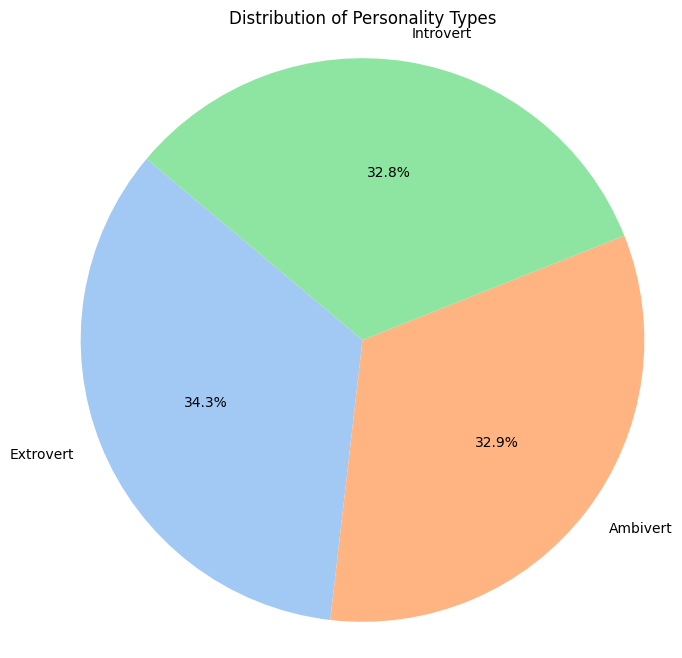

In [8]:
personality_counts = df['personality_type'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(personality_counts, labels=personality_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribution of Personality Types')
plt.axis('equal')
plt.show()

In [9]:
numerical_col = df.select_dtypes(include=np.number).columns

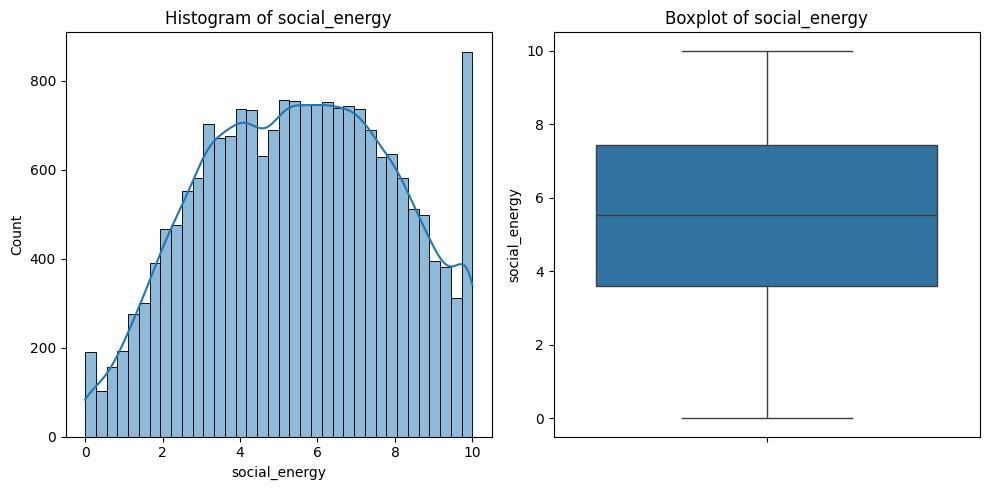

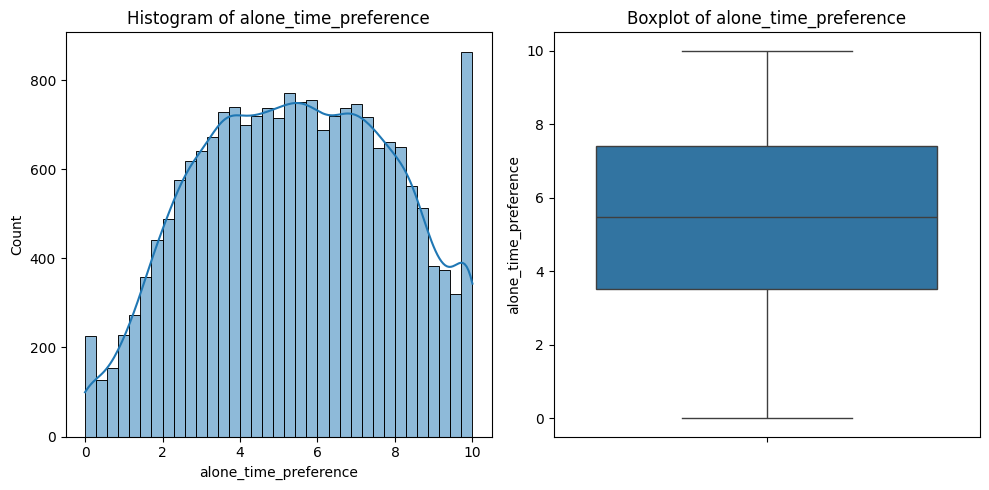

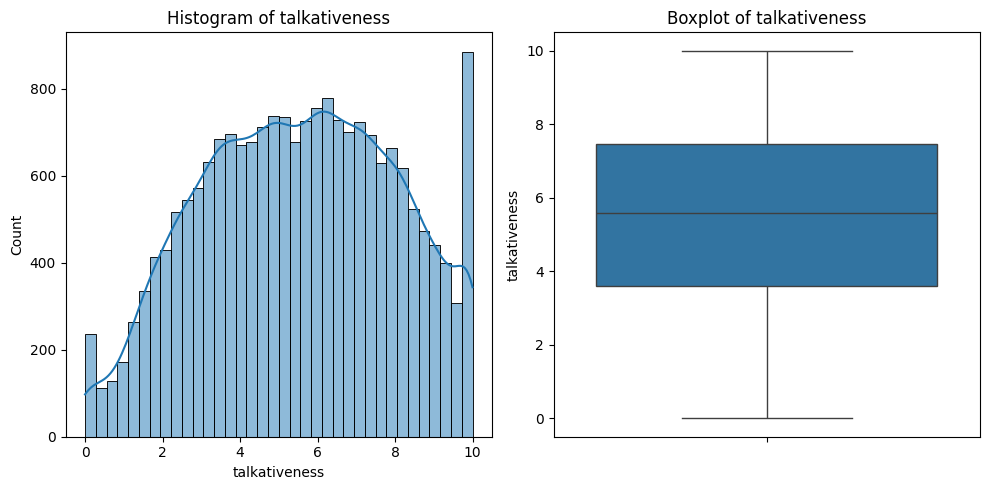

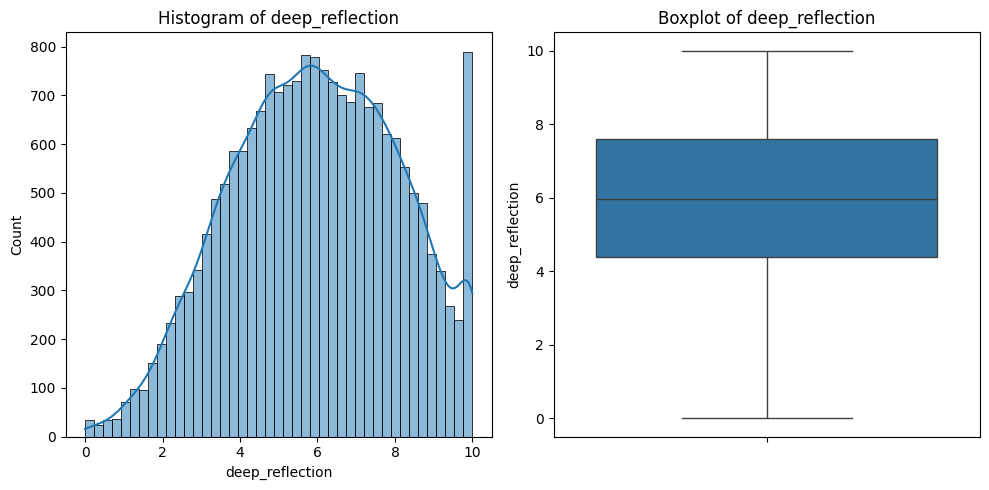

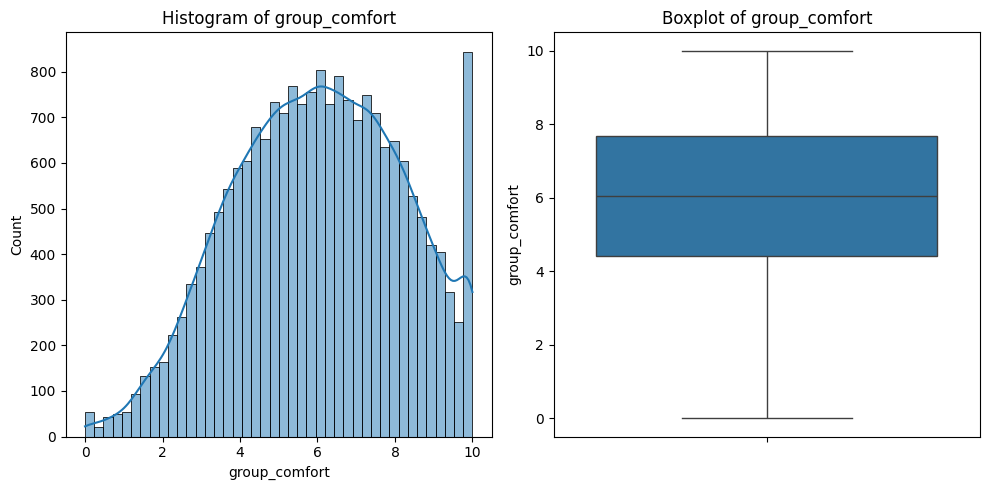

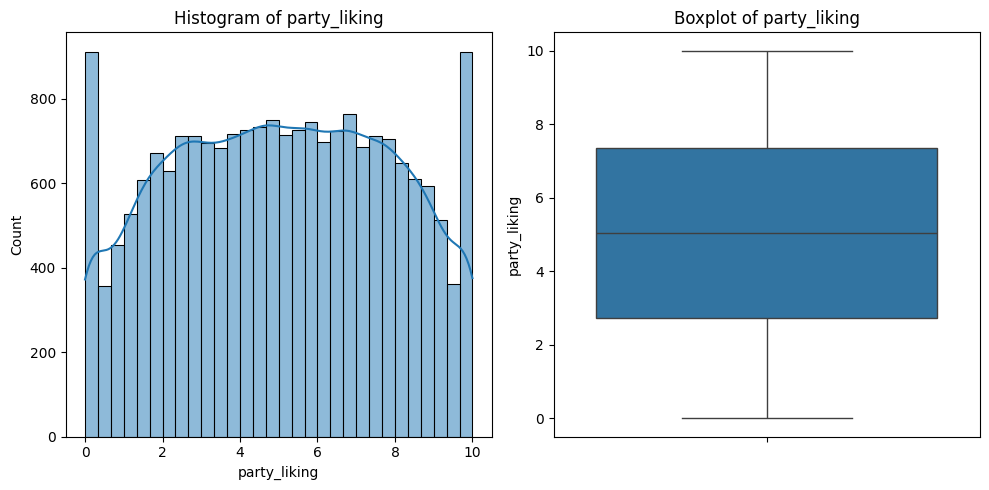

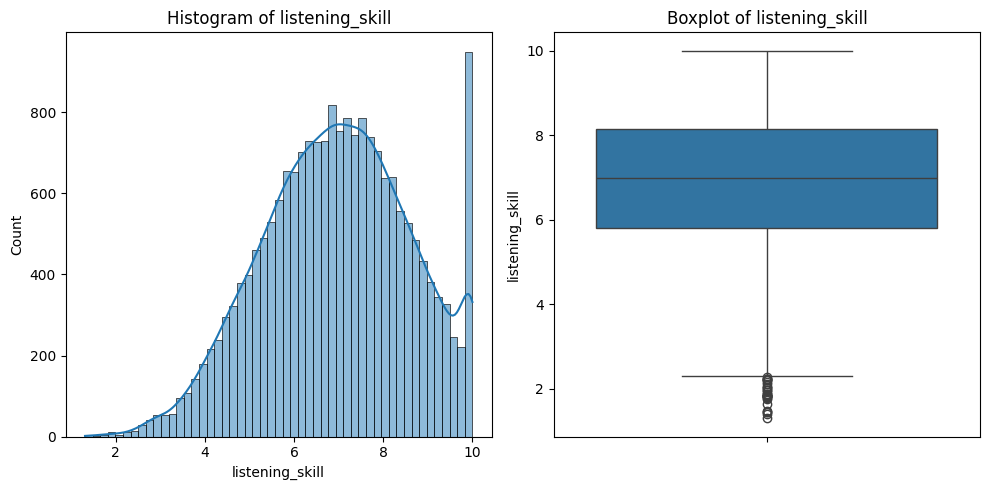

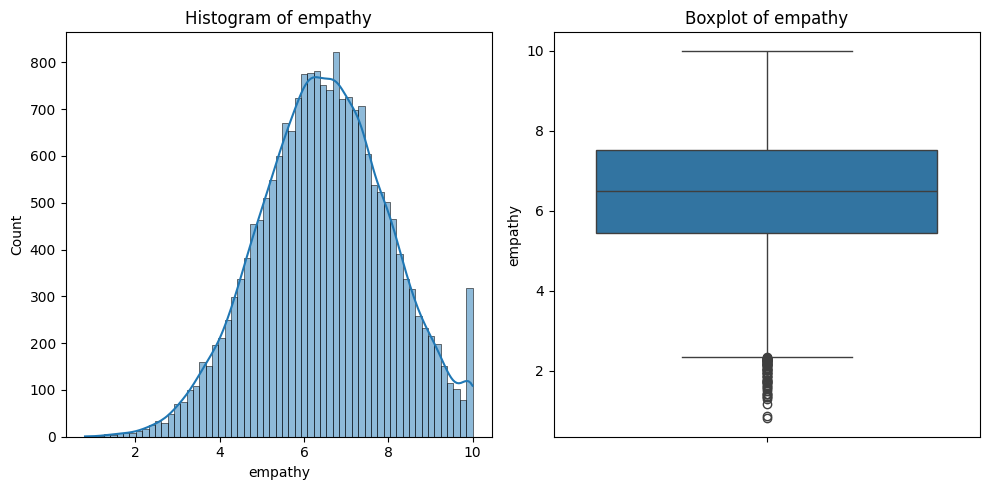

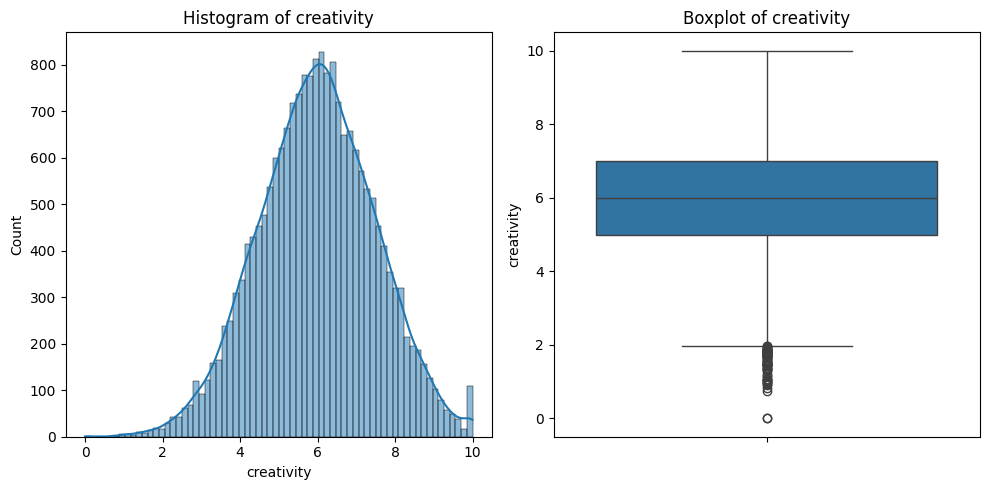

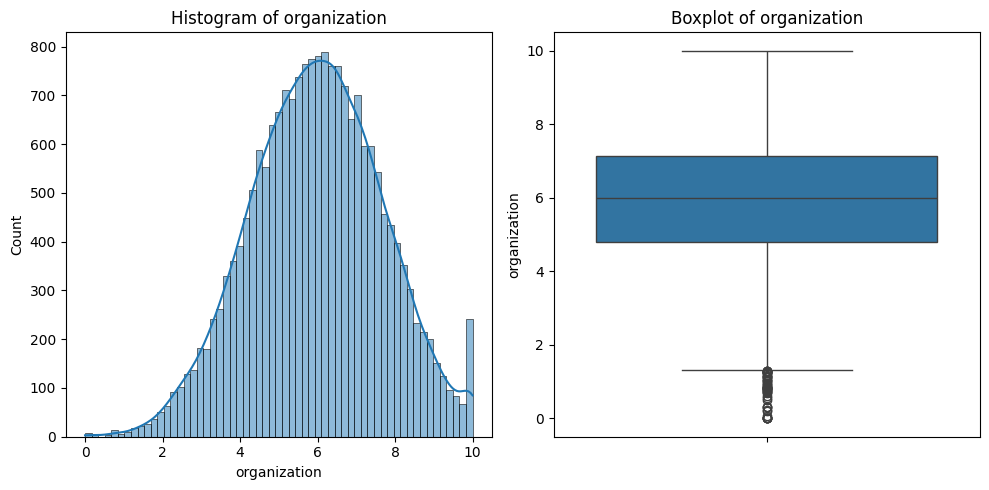

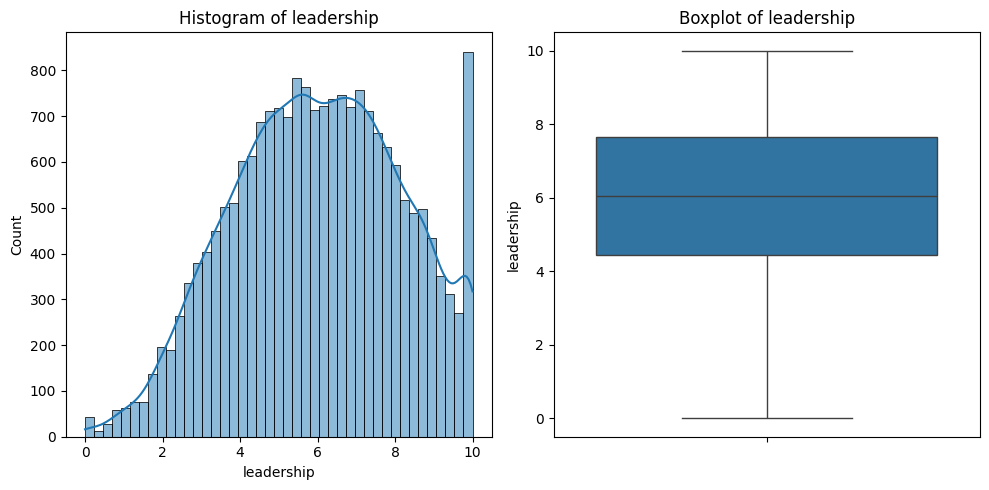

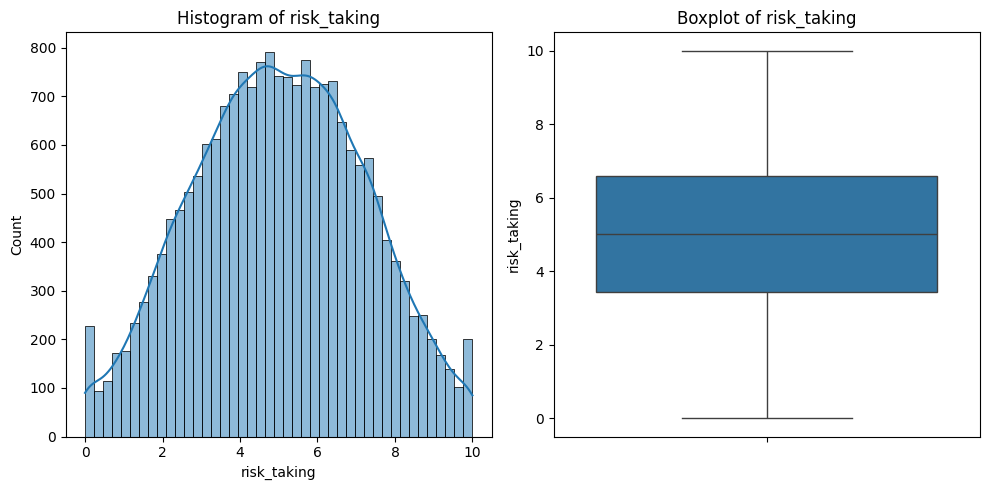

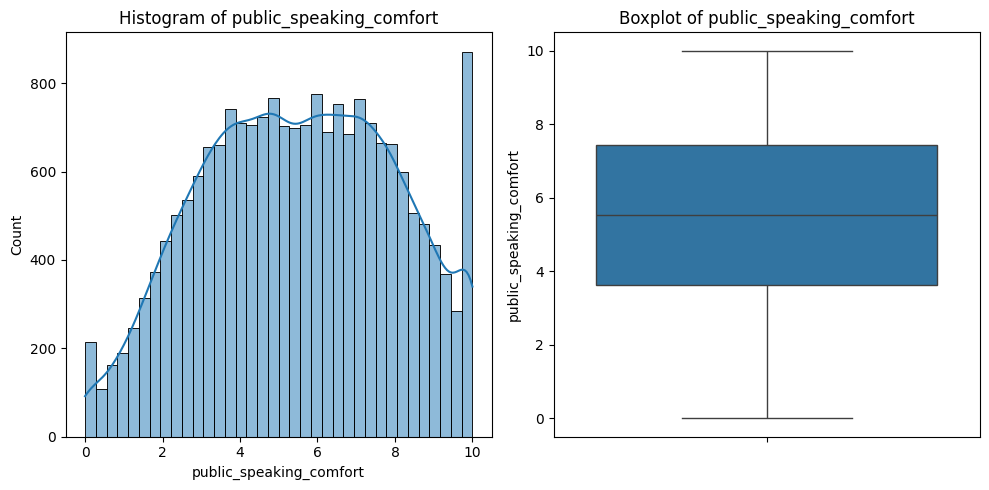

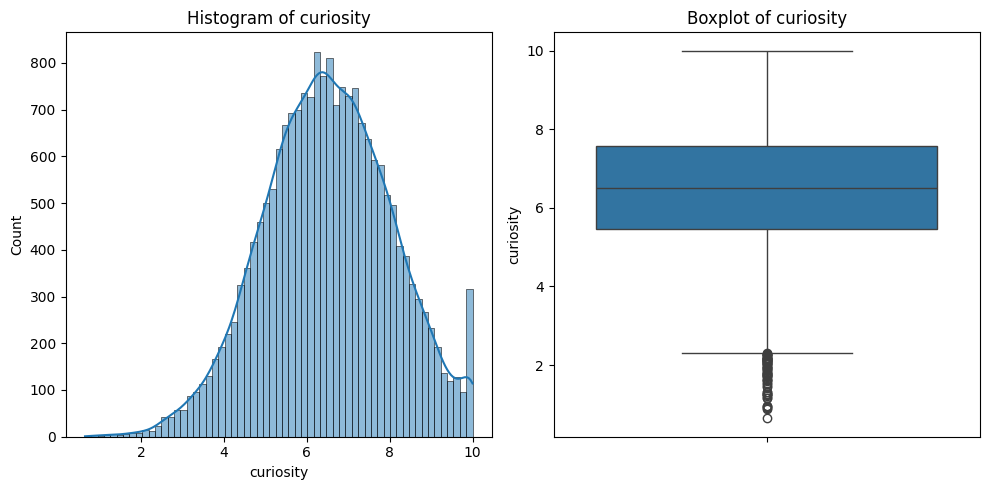

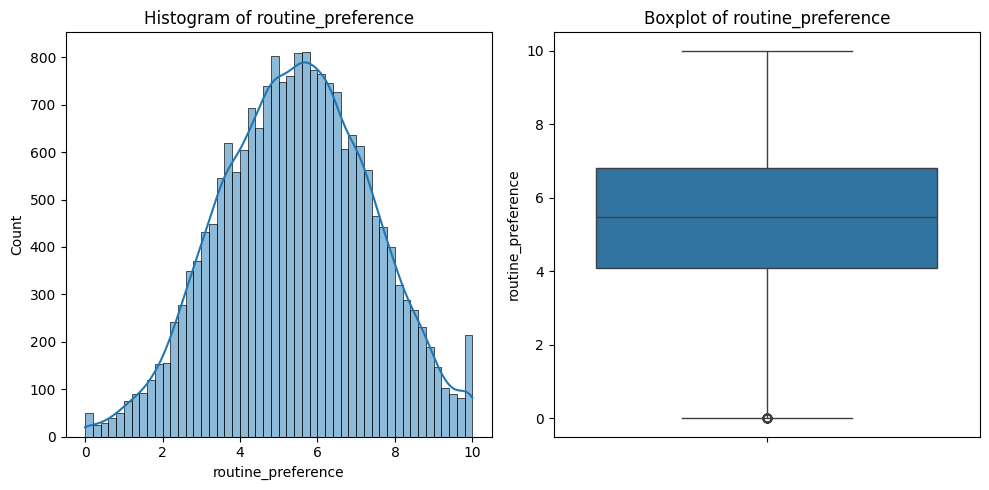

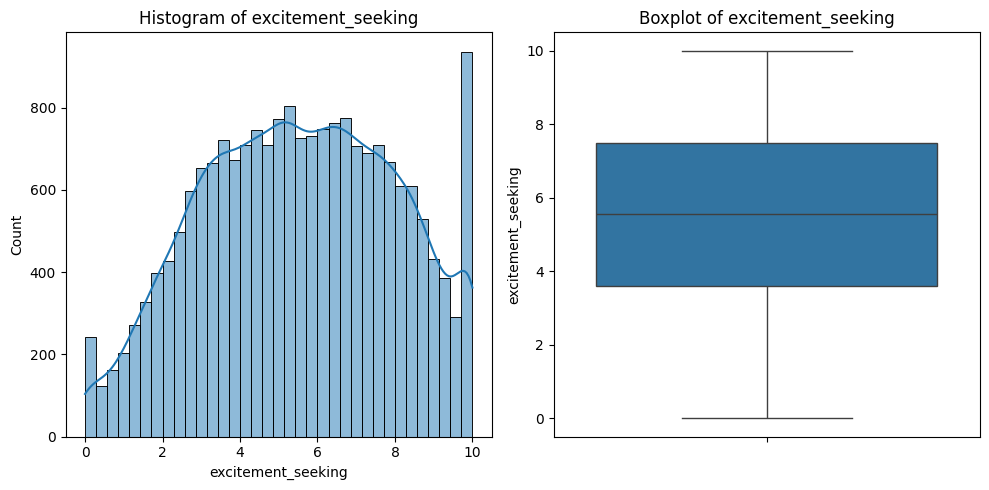

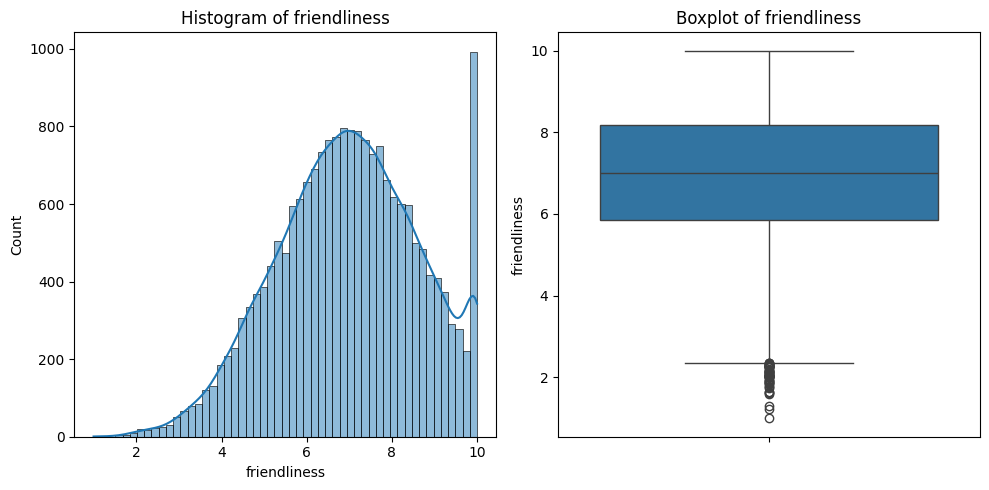

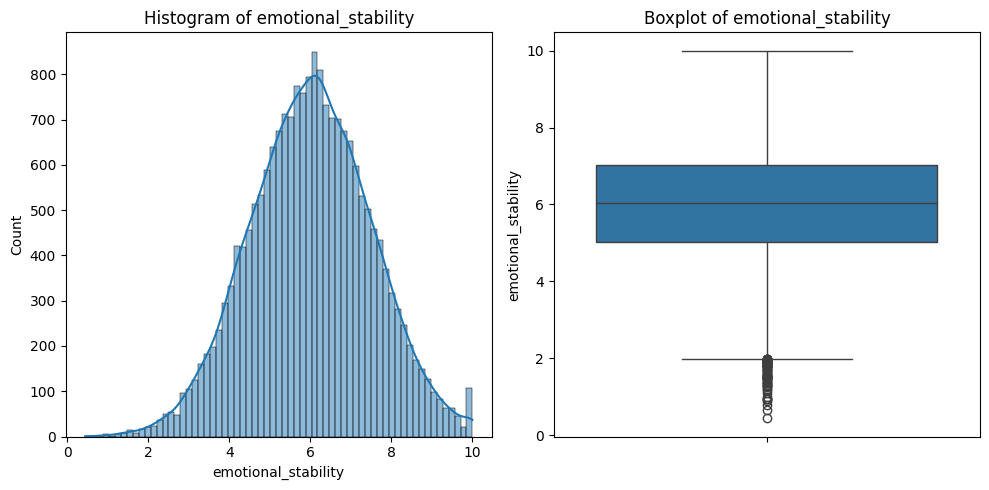

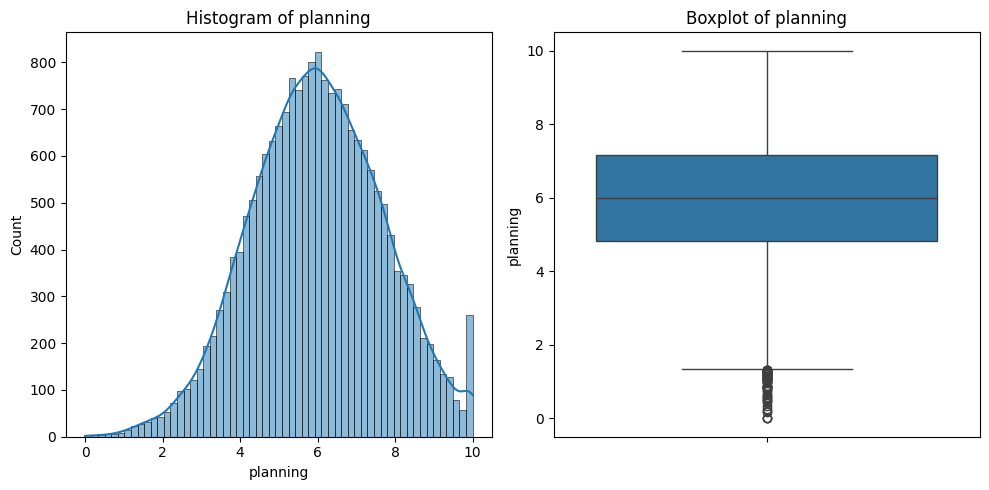

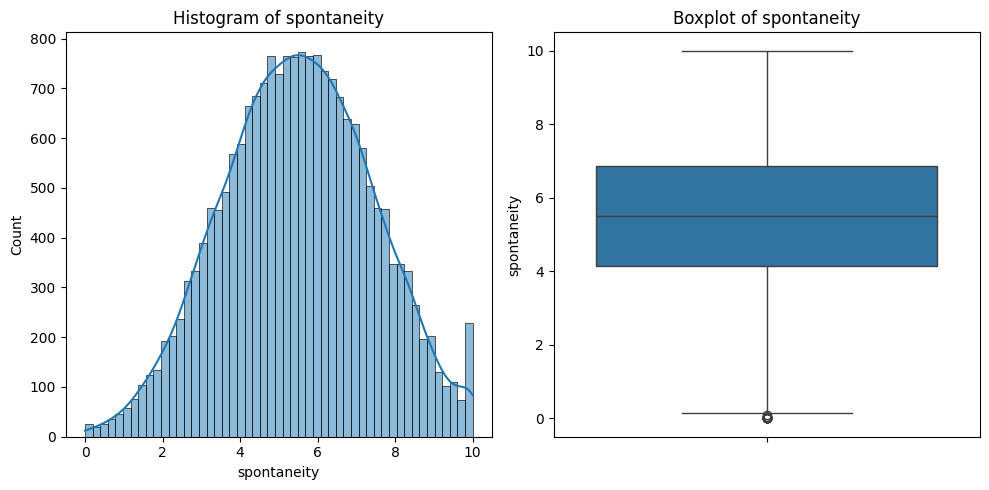

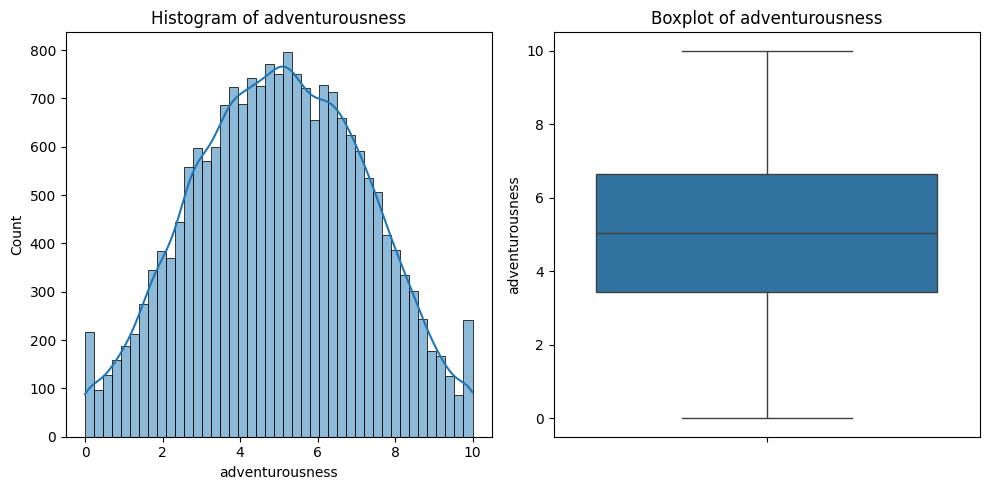

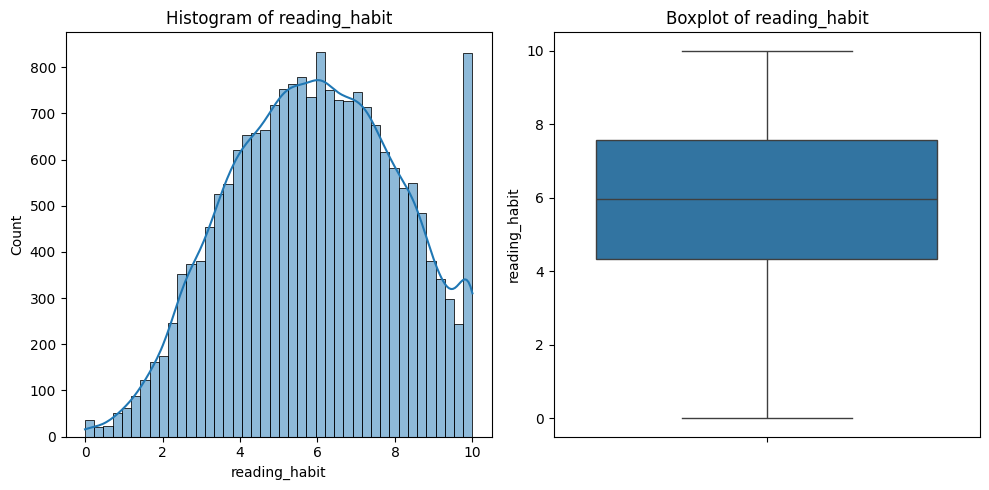

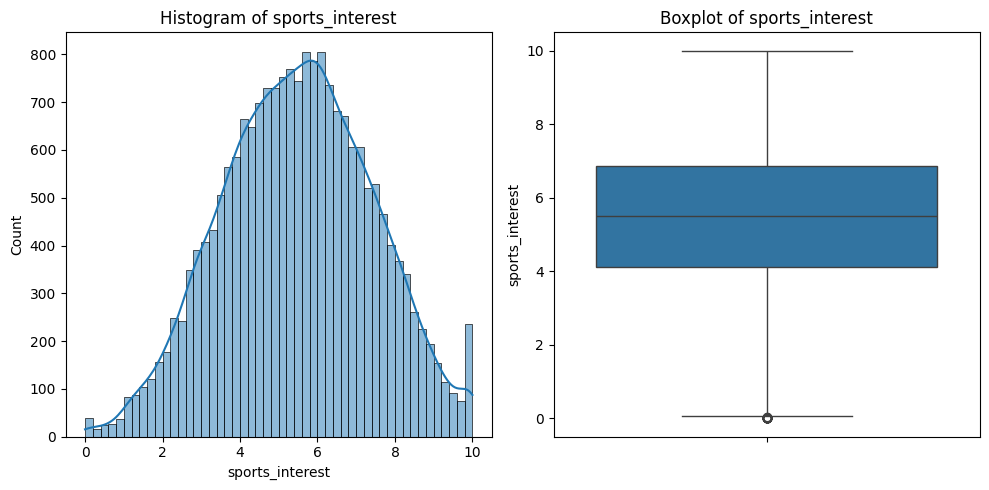

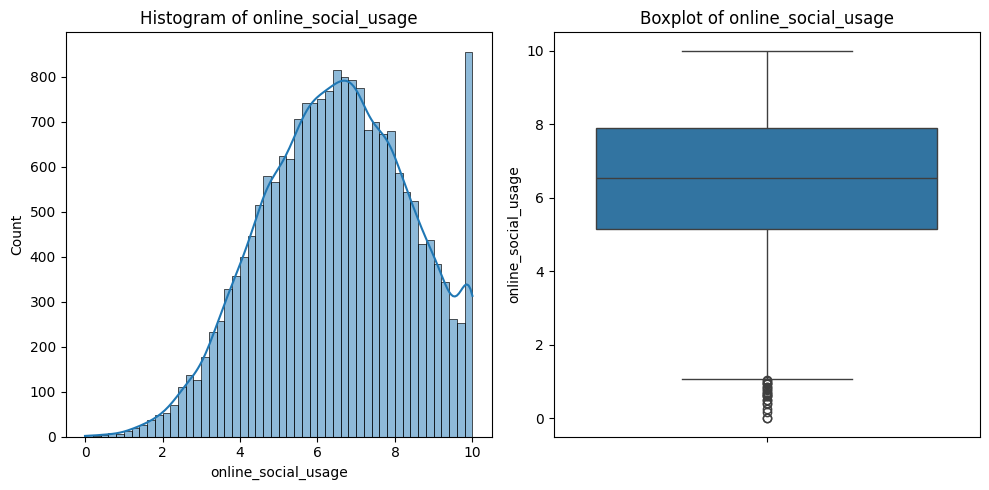

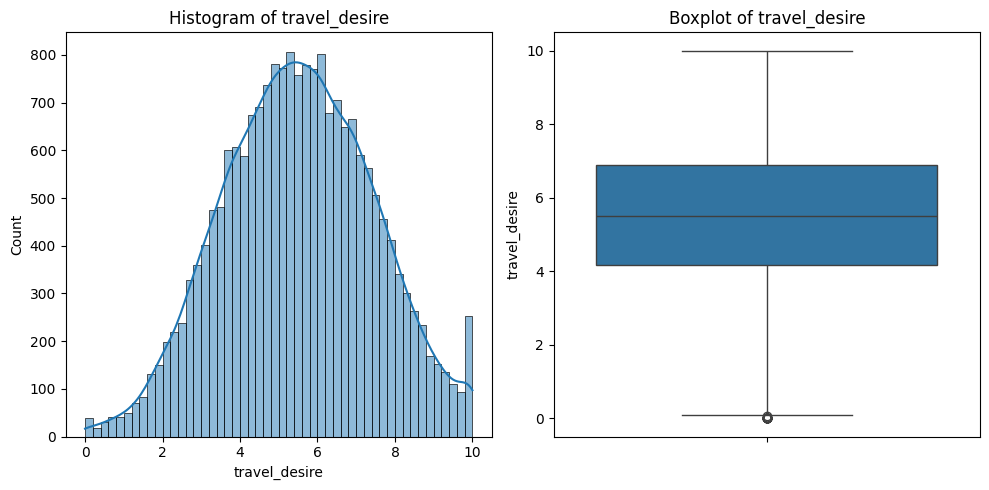

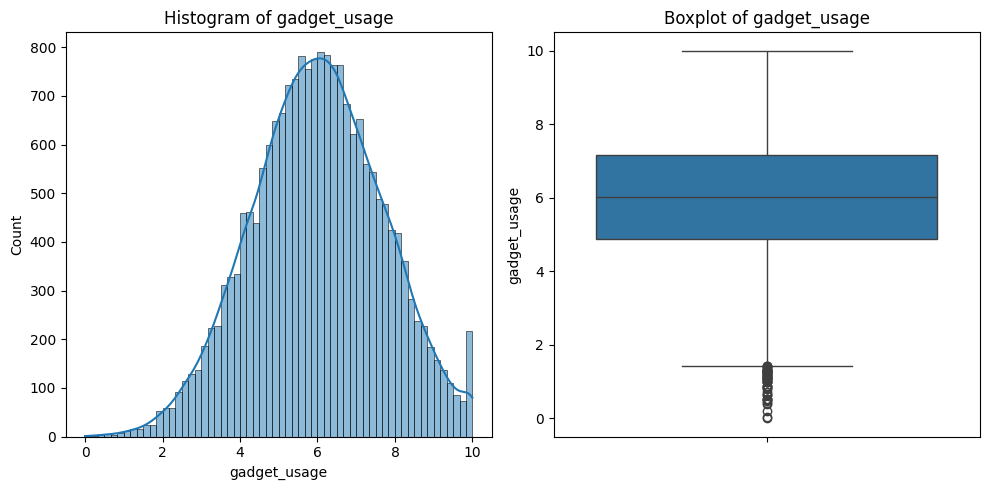

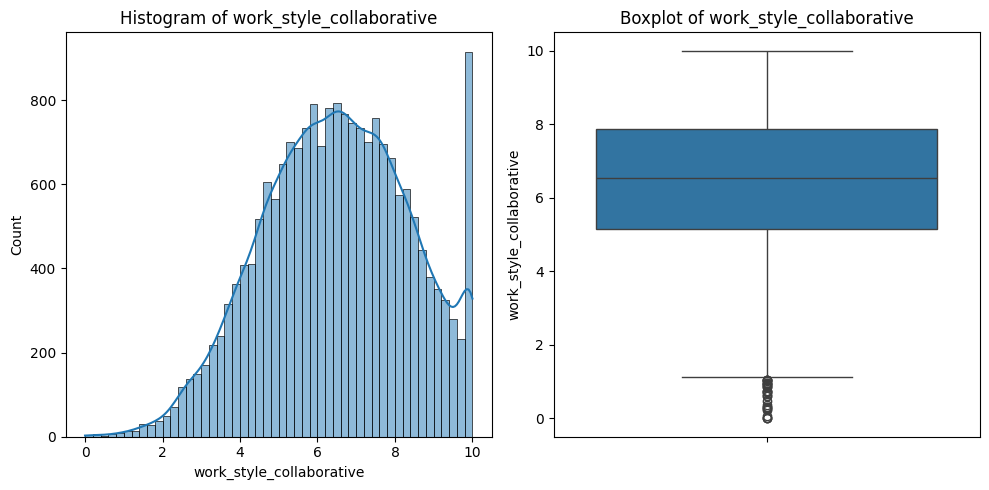

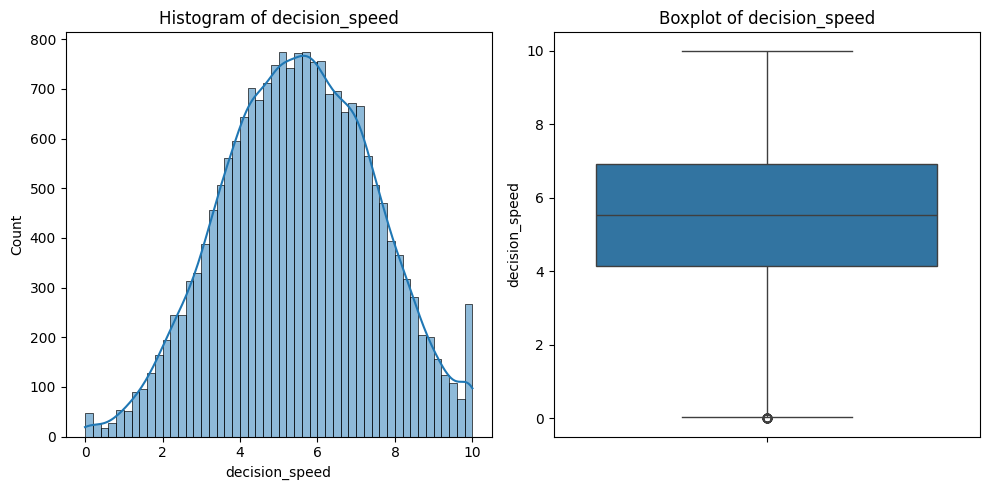

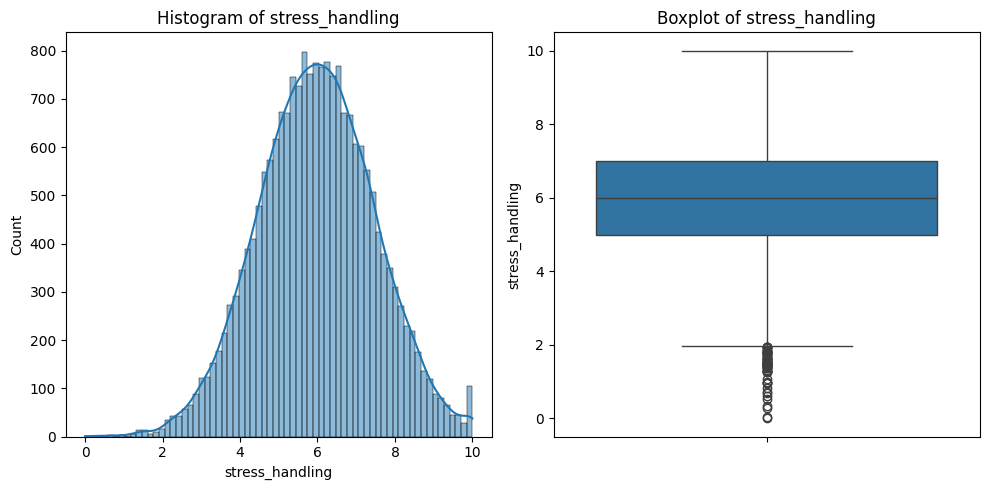

In [10]:
for col in numerical_col:
  fig, axes = plt.subplots(1, 2, figsize=(10,5))
  sns.histplot(df[col], ax=axes[0], kde=True)
  axes[0].set_title(f'Histogram of {col}')

  sns.boxplot(df[col], ax=axes[1])
  axes[1].set_title(f'Boxplot of {col}')

  plt.tight_layout()
  plt.show()

In [11]:
df.drop("personality_type", axis=1).corr()

,social_energy,alone_time_preference,talkativeness,deep_reflection,group_comfort,party_liking,listening_skill,empathy,creativity,organization,...,spontaneity,adventurousness,reading_habit,sports_interest,online_social_usage,travel_desire,gadget_usage,work_style_collaborative,decision_speed,stress_handling
social_energy,1.000000,-0.654726,0.657548,-0.595024,0.600819,0.696256,-0.391711,-0.210702,0.003439,-0.381587,...,0.516319,0.602295,-0.593950,0.515184,0.513714,0.505383,0.385225,0.505482,0.511334,-0.001252
alone_time_preference,-0.654726,1.000000,-0.658442,0.598747,-0.606488,-0.702538,0.395045,0.209842,-0.000802,0.394110,...,-0.518212,-0.599756,0.606381,-0.523267,-0.512948,-0.519675,-0.398298,-0.509340,-0.526784,0.002054
talkativeness,0.657548,-0.658442,1.000000,-0.595642,0.602341,0.699113,-0.396942,-0.206566,0.000732,-0.395587,...,0.510880,0.605093,-0.605081,0.523663,0.515386,0.511840,0.392204,0.513349,0.519035,-0.002229
deep_reflection,-0.595024,0.598747,-0.595642,1.000000,-0.545189,-0.635852,0.359396,0.189660,0.007595,0.359004,...,-0.459011,-0.543586,0.546049,-0.466185,-0.464402,-0.459070,-0.355450,-0.460659,-0.470996,0.002721
group_comfort,0.600819,-0.606488,0.602341,-0.545189,1.000000,0.643558,-0.368349,-0.189119,0.008365,-0.359493,...,0.468917,0.545587,-0.555507,0.479155,0.466763,0.464743,0.362587,0.475264,0.475904,-0.005268
party_liking,0.696256,-0.702538,0.699113,-0.635852,0.643558,1.000000,-0.413945,-0.221757,-0.000558,-0.415305,...,0.546361,0.635631,-0.640000,0.555671,0.539368,0.543858,0.414924,0.542184,0.549641,-0.012387
listening_skill,-0.391711,0.395045,-0.396942,0.359396,-0.368349,-0.413945,1.000000,0.124744,-0.010125,0.224087,...,-0.306856,-0.351312,0.357068,-0.307160,-0.307916,-0.307071,-0.237891,-0.299893,-0.298741,-0.008031
empathy,-0.210702,0.209842,-0.206566,0.189660,-0.189119,-0.221757,0.124744,1.000000,-0.013908,0.134095,...,-0.168120,-0.187131,0.194420,-0.165008,-0.160410,-0.164178,-0.125468,-0.172934,-0.167321,-0.003407
creativity,0.003439,-0.000802,0.000732,0.007595,0.008365,-0.000558,-0.010125,-0.013908,1.000000,0.003087,...,0.001773,0.003576,0.003189,-0.002150,-0.008520,0.002487,0.000121,0.003696,0.001499,-0.000754
organization,-0.381587,0.394110,-0.395587,0.359004,-0.359493,-0.415305,0.224087,0.134095,0.003087,1.000000,...,-0.303235,-0.353344,0.360127,-0.302548,-0.300454,-0.303142,-0.236453,-0.304044,-0.298850,0.016673


### Splitting the data

In [12]:
X = df.drop('personality_type', axis=1)

In [13]:
y = df['personality_type']

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

### Preprocessing

In [16]:
from sklearn.preprocessing import StandardScaler

In [17]:
scaler = StandardScaler()

In [18]:
X_train_scaled = scaler.fit_transform(X_train)

In [19]:
X_test_scaled = scaler.transform(X_test)

In [20]:
from sklearn.preprocessing import LabelEncoder

In [21]:
le = LabelEncoder()

In [22]:
y_train_encoded = le.fit_transform(y_train)

In [23]:
y_test_encoded = le.transform(y_test)

### Modelling

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score, roc_curve

In [25]:
def evaluate_model(model):
  preds = model.predict(X_test_scaled)

  ConfusionMatrixDisplay.from_estimator(model, X_test_scaled, y_test_encoded, display_labels=le.classes_)
  plt.show()

  print(classification_report(y_test_encoded, preds, target_names=le.classes_))

  print(f'Accuracy Score: {accuracy_score(y_test_encoded, preds)}')
  print(f'F1 Score: {f1_score(y_test_encoded, preds, average="micro")}')

Using Logistic Reggression

In [26]:
from sklearn.linear_model import LogisticRegression

In [27]:
log_model = LogisticRegression(random_state=101)

In [28]:
log_model.fit(X_train_scaled, y_train_encoded)

LogisticRegression(random_state=101)

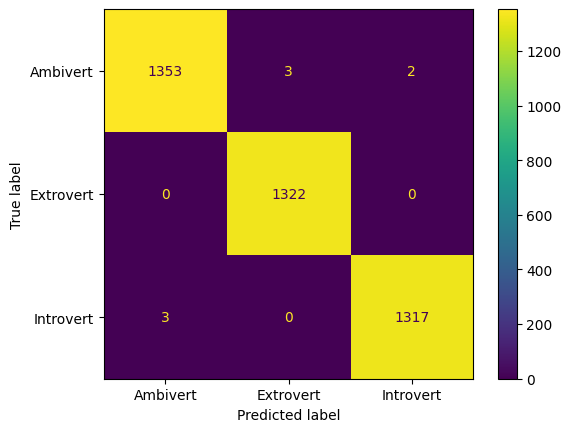

              precision    recall  f1-score   support

    Ambivert       1.00      1.00      1.00      1358
   Extrovert       1.00      1.00      1.00      1322
   Introvert       1.00      1.00      1.00      1320

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000

Accuracy Score: 0.998
F1 Score: 0.998


In [29]:
evaluate_model(log_model)

Using SVM

In [30]:
from sklearn.svm import SVC

In [31]:
svc_model = SVC(random_state=101)

In [32]:
svc_model.fit(X_train_scaled, y_train_encoded)

SVC(random_state=101)

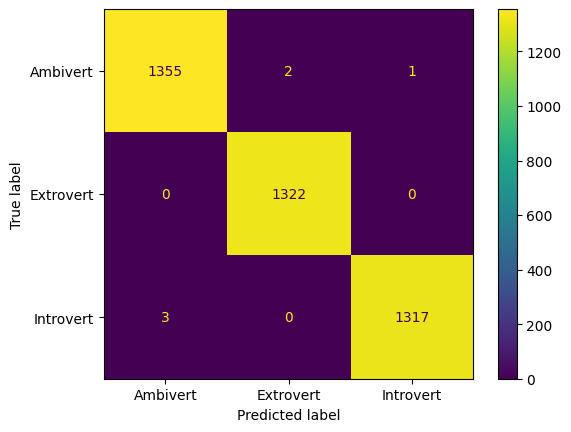

              precision    recall  f1-score   support

    Ambivert       1.00      1.00      1.00      1358
   Extrovert       1.00      1.00      1.00      1322
   Introvert       1.00      1.00      1.00      1320

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000

Accuracy Score: 0.9985
F1 Score: 0.9985


In [33]:
evaluate_model(svc_model)

Using Adaptive Boosting

In [34]:
from sklearn.ensemble import AdaBoostClassifier

In [35]:
ada_boost_model = AdaBoostClassifier(random_state=101)

In [36]:
ada_boost_model.fit(X_train_scaled, y_train_encoded)

AdaBoostClassifier(random_state=101)

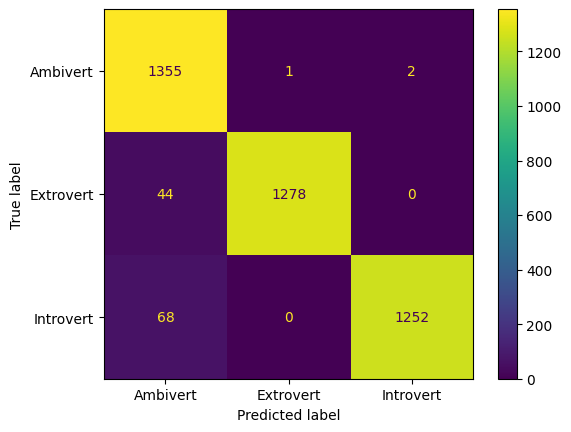

              precision    recall  f1-score   support

    Ambivert       0.92      1.00      0.96      1358
   Extrovert       1.00      0.97      0.98      1322
   Introvert       1.00      0.95      0.97      1320

    accuracy                           0.97      4000
   macro avg       0.97      0.97      0.97      4000
weighted avg       0.97      0.97      0.97      4000

Accuracy Score: 0.97125
F1 Score: 0.97125


In [37]:
evaluate_model(ada_boost_model)

using Gradient Boosting Classifier

In [38]:
from sklearn.ensemble import GradientBoostingClassifier

In [39]:
gbc = GradientBoostingClassifier(random_state=101)

In [40]:
gbc.fit(X_train_scaled, y_train_encoded)

GradientBoostingClassifier(random_state=101)

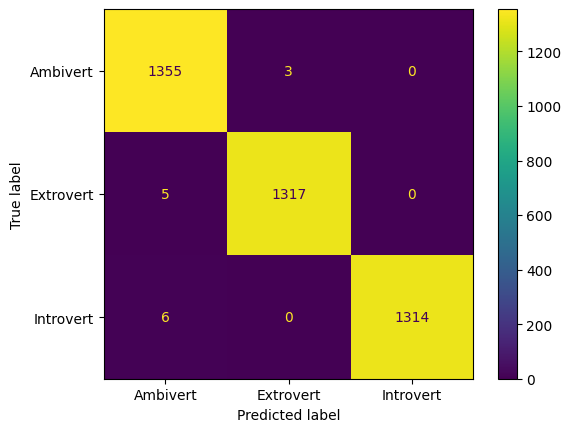

              precision    recall  f1-score   support

    Ambivert       0.99      1.00      0.99      1358
   Extrovert       1.00      1.00      1.00      1322
   Introvert       1.00      1.00      1.00      1320

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000

Accuracy Score: 0.9965
F1 Score: 0.9965


In [41]:
evaluate_model(gbc)

using the xgboost classifier

In [42]:
from xgboost import XGBClassifier

In [43]:
xgb_model = XGBClassifier(random_state=101)

In [44]:
xgb_model.fit(X_train_scaled, y_train_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

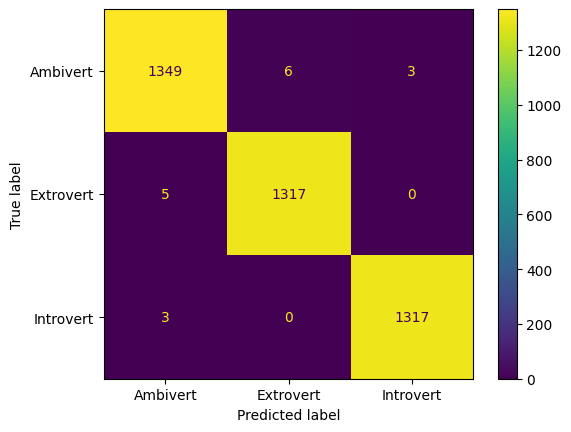

              precision    recall  f1-score   support

    Ambivert       0.99      0.99      0.99      1358
   Extrovert       1.00      1.00      1.00      1322
   Introvert       1.00      1.00      1.00      1320

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000

Accuracy Score: 0.99575
F1 Score: 0.99575


In [45]:
evaluate_model(xgb_model)

Model comparison

In [46]:
models = {
    "log_model": log_model,
    "svc_model": svc_model,
    "ada_boost_model": ada_boost_model,
    "gbc": gbc,
    "xgb_model": xgb_model
}

In [51]:
accuracy_scores = []
micro_f1_scores = []

In [52]:
def evaluate_models(model):
  preds = model.predict(X_test_scaled)

  accuracy_scores.append(accuracy_score(y_test_encoded, preds))
  micro_f1_scores.append(f1_score(y_test_encoded, preds, average="micro"))

In [53]:
for model_name, model in models.items():
  evaluate_models(model)

In [54]:
model_comparison = pd.DataFrame({
    "Model": list(models.keys()),
    "Accuracy Score": accuracy_scores,
    "Weighted F1 Score": micro_f1_scores
})

In [55]:
model_comparison

,Model,Accuracy Score,Weighted F1 Score
0,log_model,0.99800,0.99800
1,svc_model,0.99850,0.99850
2,ada_boost_model,0.97125,0.97125
3,gbc,0.99650,0.99650
4,xgb_model,0.99575,0.99575


Best performing model is the svc_model

### Final Model Training

In [56]:
final_model = SVC(random_state=101, probability=True)

In [57]:
X.head()

,social_energy,alone_time_preference,talkativeness,deep_reflection,group_comfort,party_liking,listening_skill,empathy,creativity,organization,...,spontaneity,adventurousness,reading_habit,sports_interest,online_social_usage,travel_desire,gadget_usage,work_style_collaborative,decision_speed,stress_handling
0,6.794295,3.854670,8.725446,2.515151,7.097368,8.588762,6.774799,6.430132,6.142968,0.000000,...,4.853313,8.257134,5.270555,10.000000,9.154296,4.816422,9.191711,8.313590,8.032376,7.176905
1,6.378988,5.731157,7.029529,7.274493,4.111199,3.258248,5.550909,3.958179,6.149457,4.530322,...,6.067201,6.289347,5.753165,5.334303,4.683781,4.725666,5.956141,5.890619,3.158988,3.423577
2,7.459421,6.322263,3.922269,4.622261,5.343276,7.452152,9.483990,6.127654,7.032017,7.092078,...,5.524244,9.238784,5.250405,3.153540,5.000338,6.139166,6.033048,5.807500,4.571003,5.647480
3,6.159626,3.097837,6.019093,1.965440,7.837140,10.000000,9.436733,8.949684,8.923875,5.232694,...,4.327018,8.489791,5.312617,8.379936,7.601946,6.370056,5.410145,6.671781,6.600233,5.870088
4,5.568462,6.986722,3.913240,9.926161,1.650483,0.362298,7.470387,6.756837,9.507803,6.378051,...,5.187689,3.167217,7.060235,2.333388,7.771569,5.534336,5.704598,5.832968,5.813099,3.758084


In [58]:
y.head()

,personality_type
0,Extrovert
1,Ambivert
2,Ambivert
3,Extrovert
4,Introvert


In [59]:
from sklearn.preprocessing import StandardScaler

In [60]:
scaler = StandardScaler()

In [61]:
X_scaled = scaler.fit_transform(X)

In [62]:
from sklearn.preprocessing import LabelEncoder

In [63]:
le_encoder = LabelEncoder()

In [64]:
y_encoded = le_encoder.fit_transform(y)

In [65]:
final_model.fit(X_scaled, y_encoded)

SVC(probability=True, random_state=101)

In [66]:
import joblib

In [67]:
joblib.dump(list(X.columns), "columns_names.pkl")

['columns_names.pkl']

In [68]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [69]:
joblib.dump(le_encoder, "label_encoder.pkl")

['label_encoder.pkl']

In [70]:
joblib.dump(final_model, "final_model.pkl")

['final_model.pkl']

In [71]:
from google.colab import files

In [72]:
files.download("columns_names.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [73]:
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [74]:
files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [75]:
files.download("final_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>